# Universal ODE for Lotka–Volterra: recovering the unknown interaction term

This **deep-dive tutorial** demonstrates the **Universal ODE (UODE)** approach for the classic Lotka–Volterra predator-prey system.

**Key idea.** We *partially* know the dynamics:
- The prey self-growth term $\alpha x$ is **known**.
- The predator self-decay term $-\delta y$ is **known**.
- The interaction terms ($-\beta xy$ for prey, $+\gamma xy$ for predators) are **unknown** and replaced by a sparse polynomial $U(\Theta, x, y)$.

**Goal.** From noisy observations of prey $x$ only, jointly infer:
- The sparse coefficient matrix $\Theta$ of the unknown interaction term.
- The diffusion $\sigma_x$ and observation noise $\sigma_y$.

**What is known.**
- Known linear terms: prey growth $\alpha x$ and predator decay $-\delta y$.
- Initial state distribution $x_0 \sim \mathcal{N}(\mu_0, \sigma_0^2 I)$.
- Observation operator $H$ (observes prey $x$ only: $H = [1, 0]$).
- Polynomial library $\phi(x, y)$ (all monomials in $x, y$ up to degree 2).

**What is inferred.**
- $\Theta \sim \mathrm{Laplace}(0, 0.5)$ — sparse interaction coefficients.
- $\sigma_x \sim \mathrm{HalfNormal}(0.1)$ — diffusion coefficient.
- $\sigma_y \sim \mathrm{HalfNormal}(0.5)$ — observation noise std.

## Lotka–Volterra Model

### True (fully known) ODE

The full Lotka–Volterra system is

$$
\dot{x} = \alpha x - \beta x y, \qquad \dot{y} = \gamma x y - \delta y,
$$

where $x$ is prey population and $y$ is predator population.

### UODE decomposition

We split the drift into a **known part** and an **unknown interaction part**:

$$
\dot{x} = \underbrace{\alpha x}_{\text{known}} + \underbrace{U_x(\Theta, x, y)}_{\text{unknown interaction}},
\qquad
\dot{y} = \underbrace{-\delta y}_{\text{known}} + \underbrace{U_y(\Theta, x, y)}_{\text{unknown interaction}},
$$

where

$$
U(\Theta, x, y) = \Theta\,\phi(x, y), \quad \phi(x,y) = [1,\ x,\ y,\ x^2,\ xy,\ y^2]^\top \in \mathbb{R}^6.
$$

The **true** interaction is recovered when $\Theta$ correctly identifies the $-\beta xy$ (prey) and $+\gamma xy$ (predator) terms.

### Observation process

Both species are observed at discrete times $t_1 < \cdots < t_n$:

$$
z_k = \begin{pmatrix} x_{t_k} \\ y_{t_k} \end{pmatrix} + \varepsilon_k, \qquad \varepsilon_k \sim \mathcal{N}(0, \sigma_y^2 I_2).
$$

Parameters: $\alpha = 1.0$, $\beta = 0.1$, $\gamma = 0.075$, $\delta = 1.5$.

In [1]:
import jax.numpy as jnp
import jax.random as jr
import numpyro
import numpyro.distributions as dist
from numpyro.infer import SVI, Trace_ELBO, Predictive
from numpyro.infer.autoguide import AutoDelta

import dynestyx as dsx
from dynestyx import (
    ContinuousTimeStateEvolution,
    DynamicalModel,
    Filter,
    LinearGaussianObservation,
    SDESimulator,
)

import matplotlib.pyplot as plt

## True system

We define the true system via a Lotka–Volterra drift. This is what we are trying to recover -- but we only give the model the **linear** part.

In [2]:
# Lotka-Volterra parameters (fixed; not inferred)
_alpha = 1.0    # prey self-growth
_beta  = 0.1    # prey-predator interaction (unknown to model)
_gamma = 0.075  # predator-prey interaction (unknown to model)
_delta = 1.5    # predator self-decay

state_dim = 2   # (x=prey, y=predator)


def lv_true_drift(x):
    """Full true Lotka-Volterra drift."""
    prey, pred = x[0], x[1]
    return jnp.array([
        _alpha * prey - _beta * prey * pred,
        _gamma * prey * pred - _delta * pred,
    ])


def lv_known_drift(x):
    """Only the known linear part: alpha*x and -delta*y."""
    prey, pred = x[0], x[1]
    return jnp.array([
        _alpha * prey,
        -_delta * pred,
    ])

## Model configuration

| Symbol | Role | Value | Status |
|---|---|---|---|
| $\sigma_x^{\mathrm{true}}$ | SDE diffusion (data generation) | `0.05` | **inferred** |
| $\sigma_y^{\mathrm{true}}$ | observation noise std | `0.5` | **inferred** |
| $x_0$ | initial prey/predator | `(10, 5)` | known |
| $\Delta t$ | observation spacing | `0.5` | known |
| $T$ | time span | `[0, 30)` | known |
| $H$ | observation matrix | `[1, 0]` (prey only) | known |

In [3]:
sigma_x_true = 0.05   # true diffusion — inferred during model discovery
sigma_y_true = 0.5    # true obs noise  — inferred during model discovery

obs_times = jnp.arange(0.0, 30.0, 0.2)  # 150 observations (every 0.2s)

# Observe both species: H = I_2
H_obs = jnp.eye(state_dim)
observation_dim = state_dim

# Initial condition: near (10, 5) with small uncertainty
x0_mean = jnp.array([10.0, 5.0])
x0_cov  = 0.5**2 * jnp.eye(state_dim)

initial_condition_kwargs = dict(
    initial_condition=dist.MultivariateNormal(
        loc=x0_mean,
        covariance_matrix=x0_cov,
    )
)

key = jr.PRNGKey(42)
key, k_data, k_svi, k_filter = jr.split(key, 4)

# Minimum diffusion to keep the EKF covariance well-conditioned
_DIFFUSION_FLOOR = 1e-2


def make_state_evolution(drift_fn, diffusion_coeff):
    """Wrap a drift into ContinuousTimeStateEvolution with isotropic noise."""
    safe_coeff = jnp.maximum(diffusion_coeff, _DIFFUSION_FLOOR)
    return ContinuousTimeStateEvolution(
        drift=lambda x, u, t: drift_fn(x),
        diffusion=dsx.ScalarDiffusion(safe_coeff, bm_dim=state_dim)
    )

## Data generation

Simulate from the **true** Lotka–Volterra SDE using the full known drift.

In [4]:
def model_with_true_drift(obs_times=None, obs_values=None, predict_times=None):
    return dsx.sample("f", DynamicalModel(
        state_evolution=make_state_evolution(lv_true_drift, sigma_x_true),
        observation_model=LinearGaussianObservation(
            H=H_obs,
            R=sigma_y_true**2 * jnp.eye(observation_dim),
        ),
        **initial_condition_kwargs,
    ), obs_times=obs_times, obs_values=obs_values, predict_times=predict_times)


predictive = Predictive(model_with_true_drift, num_samples=1, exclude_deterministic=False)
with SDESimulator(dt0=1e-3):
    synthetic = predictive(k_data, predict_times=obs_times)

obs_values = synthetic["f_observations"][0, 0]   # (T, 2) — both species
states     = synthetic["f_states"][0, 0]          # (T, 2) — full state
times_1d   = jnp.asarray(obs_times)

/Users/danwaxman/Documents/dynestyx/dynestyx/models/core.py:228: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  return StochasticContinuousTimeStateEvolution(
/Users/danwaxman/.local/share/uv/python/cpython-3.12.10-macos-aarch64-none/lib/python3.12/dataclasses.py:1588: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  return obj.__class__(**changes)


### Data visualisation

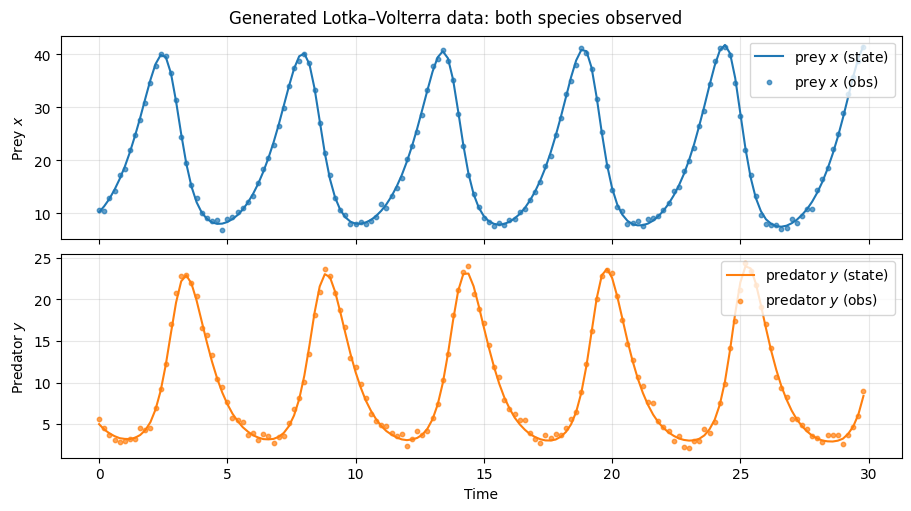

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(9, 5), sharex=True, constrained_layout=True)

axes[0].plot(times_1d, states[:, 0], label="prey $x$ (state)", color="C0")
axes[0].scatter(times_1d, obs_values[:, 0], s=10, alpha=0.7,
                label="prey $x$ (obs)", color="C0", zorder=3)
axes[0].set_ylabel("Prey $x$")
axes[0].legend(loc="upper right")
axes[0].grid(True, alpha=0.3)

axes[1].plot(times_1d, states[:, 1], label="predator $y$ (state)", color="C1")
axes[1].scatter(times_1d, obs_values[:, 1], s=10, alpha=0.7,
                label="predator $y$ (obs)", color="C1", zorder=3)
axes[1].set_ylabel("Predator $y$")
axes[1].set_xlabel("Time")
axes[1].legend(loc="upper right")
axes[1].grid(True, alpha=0.3)

fig.suptitle("Generated Lotka\u2013Volterra data: both species observed")
plt.show()

### True-model marginal log-likelihood benchmark (for convergence monitoring)

Before fitting the UODE, we compute the marginal log-likelihood (MLL) of the observed data under the **true** data-generating model using the same selected filter (continuous-time EKF).

This gives a practical reference for what a "good" likelihood looks like so we can monitor SVI convergence more efficiently. However, this is **cheating** in real applications: the true model is unknown, so this benchmark is only available in controlled synthetic experiments like this one.

In [6]:
from dynestyx.inference.filter_configs import ContinuousTimeEnKFConfig


def true_model_with_filter(obs_times=None, obs_values=None):
    with Filter(filter_config=ContinuousTimeEnKFConfig()):
        return model_with_true_drift(obs_times=obs_times, obs_values=obs_values)


key, k_true_mll = jr.split(key)
true_mll = Predictive(
    true_model_with_filter,
    num_samples=1,
    exclude_deterministic=False,
)(k_true_mll, obs_times=obs_times, obs_values=obs_values)["f_marginal_loglik"]

true_mll = float(jnp.asarray(true_mll).squeeze())
print(f"Marginal log-likelihood under true model (EnKF): {true_mll:.3f}")

Marginal log-likelihood under true model (EnKF): -232.758


## Polynomial library and true coefficients

We proceed with the unknown component of the drift via dictionary learning. We use SINDy-like library terms (all monomials in $x, y$ up to degree 2):
$$\phi(x,y) = [1,\ x,\ y,\ x^2,\ xy,\ y^2].$$

The **true** interaction term uses only $xy$: coefficient $-\beta$ for prey and $+\gamma$ for predators. The known linear parts are **not** included in $\phi$ — they are handled by `lv_known_drift`.

In [7]:
TERM_NAMES = ["1", "x", "y", "x²", "xy", "y²"]
N_TERMS = len(TERM_NAMES)


def interaction_library(x):
    """Polynomial library for the unknown interaction term. Returns (N_TERMS,)."""
    prey, pred = x[0], x[1]
    return jnp.array([1.0, prey, pred, prey**2, prey * pred, pred**2])


# True Theta: only the 'xy' term (index 4) is nonzero
# Row 0 (prey):     U_x = -beta * x * y  =>  coeff at xy = -beta
# Row 1 (predator): U_y = +gamma * x * y =>  coeff at xy = +gamma
true_Theta = jnp.zeros((state_dim, N_TERMS))
true_Theta = true_Theta.at[0, 4].set(-_beta)   # prey: -beta * xy
true_Theta = true_Theta.at[1, 4].set(_gamma)    # predator: +gamma * xy

print("True interaction coefficient matrix Theta (rows: dx, dy; cols: library terms):")
print(f"  Terms: {TERM_NAMES}")
print(f"  Theta =\n{jnp.round(true_Theta, 4)}")

True interaction coefficient matrix Theta (rows: dx, dy; cols: library terms):
  Terms: ['1', 'x', 'y', 'x²', 'xy', 'y²']
  Theta =
[[ 0.          0.          0.          0.         -0.09999999  0.        ]
 [ 0.          0.          0.          0.          0.075       0.        ]]


## UODE model discovery

Build a Dynestyx SDE model that jointly infers $\Theta$, $\sigma_x$, $\sigma_y$.

The drift is:
$$
f(x) = \underbrace{f_{\text{known}}(x)}_{\alpha x,\ -\delta y} + \underbrace{\Theta\,\phi(x,y)}_{\text{unknown interaction}}.
$$

We use an EKF (via `ContinuousTimeEKFConfig`) to marginalise the continuous-time latent state during inference.

In [8]:
def uode_lv_model(obs_times=None, obs_values=None):
    # --- Unknown interaction: sparse Laplace prior on Theta ---
    # Very tight scale (0.005) strongly penalises non-zero entries -> SINDy-like sparsity
    Theta = numpyro.sample(
        "Theta",
        dist.Laplace(0.0, 0.005).expand([state_dim, N_TERMS]).to_event(2),
    )

    # --- Noise parameters ---
    # LogNormal keeps sigma_x bounded away from zero → avoids non-PD EKF covariances
    sigma_x = numpyro.sample("sigma_x", dist.LogNormal(jnp.log(0.05), 1.0))
    sigma_y = numpyro.sample("sigma_y", dist.HalfNormal(0.5))

    # --- UODE drift: known linear part + unknown polynomial interaction ---
    def drift(x):
        known = lv_known_drift(x)               # (alpha*x, -delta*y)
        phi   = interaction_library(x)          # (N_TERMS,)
        unknown = Theta @ phi                   # (state_dim,)
        return known + unknown
    
    return dsx.sample("f", DynamicalModel(
        state_evolution=make_state_evolution(drift, sigma_x),
        observation_model=LinearGaussianObservation(
            H=H_obs,
            R=sigma_y**2 * jnp.eye(observation_dim),
        ),
        **initial_condition_kwargs,
    ), obs_times=obs_times, obs_values=obs_values)

Build the data-conditioned model (filter + observations) and run SVI for MAP estimation.

**Key numerical choices:**
- **`cov_rescaling=2.0`** — inflates the diffusion coefficient inside the Riccati ODE, keeping the EnKF covariance positive-definite throughout optimisation. Without this, numerical errors accumulate after ~85 SVI steps, producing non-PD matrices and NaN losses.
- **Learning-rate decay** — exponential decay (via `optax`) prevents late-stage instability when the parameters are near the optimum and the EKF covariance is tight.
- **`init_to_value`** — initialises at the prior mode/median: $\Theta = 0$ (Laplace mode), $\sigma_x = 0.05$ (LogNormal median), $\sigma_y = 0.5$ (HalfNormal scale).
- **Dense observations + both species** — observing both prey and predator at $\Delta t = 0.2$ (150 points) provides enough signal to break library-feature collinearity and recover the correct sparse $\Theta$ via SVI/ELBO.

In [9]:
from dynestyx.inference.filter_configs import ContinuousTimeEnKFConfig

def data_conditioned_model(obs_times=None, obs_values=None):
    with Filter(filter_config=ContinuousTimeEnKFConfig(
        record_filtered_states_mean=True,
        record_filtered_states_cov=True,
    )):
        return uode_lv_model(obs_times=obs_times, obs_values=obs_values)

num_steps = 4000
optimizer = numpyro.optim.Adam(step_size=1e-3)
guide = AutoDelta(data_conditioned_model)
svi = SVI(data_conditioned_model, guide, optimizer, loss=Trace_ELBO())
svi_result = svi.run(k_svi, num_steps=num_steps, obs_times=obs_times, obs_values=obs_values)


median = guide.median(svi_result.params)
Theta_inferred   = median["Theta"]
sigma_x_inferred = float(median["sigma_x"])
sigma_y_inferred = float(median["sigma_y"])

print(f"Inferred sigma_x = {sigma_x_inferred:.4f}  (true = {sigma_x_true:.4f})")
print(f"Inferred sigma_y = {sigma_y_inferred:.4f}  (true = {sigma_y_true:.4f})")

100%|██████████| 4000/4000 [17:38<00:00,  3.78it/s, init loss: 386381.1875, avg. loss [3801-4000]: 214.0941]


Inferred sigma_x = 0.0591  (true = 0.0500)
Inferred sigma_y = 0.4179  (true = 0.5000)


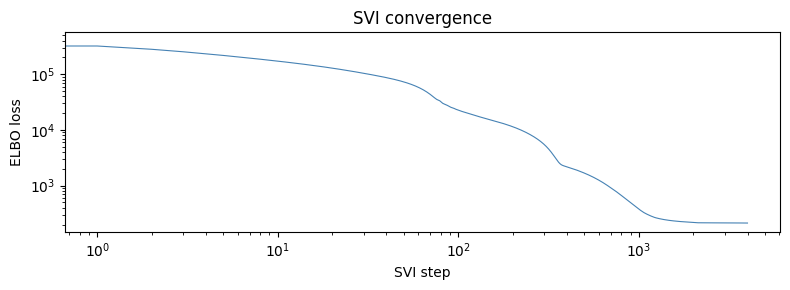

In [10]:
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(svi_result.losses, lw=0.8, color="steelblue")
ax.set_xlabel("SVI step")
ax.set_ylabel("ELBO loss")
ax.set_title("SVI convergence")
ax.set_yscale("log")
ax.set_xscale("log")
plt.tight_layout()
plt.show()

## Parameter recovery

### Interaction coefficient matrix $\Theta$

The learned $\Theta$ (rows = state dimensions, columns = library terms) should be sparse — only the
`xy` column should be non-zero, encoding the predator–prey coupling.

In [11]:
import numpy as np

print("TERM_NAMES:", TERM_NAMES)
print()
print(f"{'':>12s}  {'x-row (prey drift)':>22s}  {'y-row (predator drift)':>24s}")
print(f"{'':>12s}  {'true':>8s} {'inferred':>10s}  {'true':>8s} {'inferred':>10s}")
print("-" * 68)
for j, name in enumerate(TERM_NAMES):
    t0, t1 = float(true_Theta[0, j]), float(true_Theta[1, j])
    i0, i1 = float(Theta_inferred[0, j]), float(Theta_inferred[1, j])
    print(f"{name:>12s}  {t0:>8.4f} {i0:>10.4f}  {t1:>8.4f} {i1:>10.4f}")

TERM_NAMES: ['1', 'x', 'y', 'x²', 'xy', 'y²']

                  x-row (prey drift)    y-row (predator drift)
                  true   inferred      true   inferred
--------------------------------------------------------------------
           1    0.0000    -0.0000    0.0000     0.0001
           x    0.0000     0.0001    0.0000    -0.0000
           y    0.0000     0.0001    0.0000    -0.0000
          x²    0.0000     0.0002    0.0000    -0.0000
          xy   -0.1000    -0.1000    0.0750     0.0751
          y²    0.0000     0.0004    0.0000     0.0001


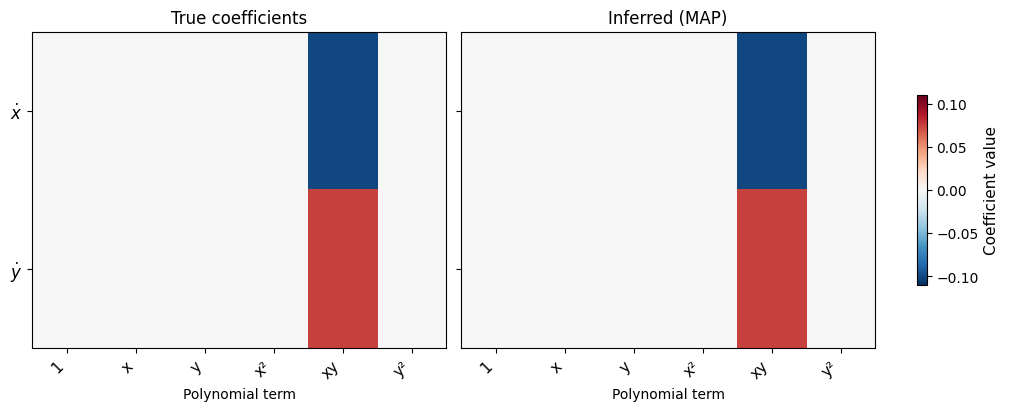

In [12]:
vmax = max(float(jnp.abs(true_Theta).max()), float(jnp.abs(Theta_inferred).max())) * 1.1

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True, constrained_layout=True)

im0 = axes[0].imshow(
    jnp.asarray(true_Theta),
    cmap="RdBu_r",
    aspect="auto",
    vmin=-vmax,
    vmax=vmax,
)
axes[0].set_xticks(range(N_TERMS))
axes[0].set_xticklabels(TERM_NAMES, rotation=45, ha="right", fontsize=11)
axes[0].set_yticks([0, 1])
axes[0].set_yticklabels([r"$\dot{x}$", r"$\dot{y}$"], fontsize=12)
axes[0].set_title("True coefficients")
axes[0].set_xlabel("Polynomial term")

im1 = axes[1].imshow(
    jnp.asarray(Theta_inferred),
    cmap="RdBu_r",
    aspect="auto",
    vmin=-vmax,
    vmax=vmax,
)
axes[1].set_xticks(range(N_TERMS))
axes[1].set_xticklabels(TERM_NAMES, rotation=45, ha="right", fontsize=11)
axes[1].set_yticks([0, 1])
axes[1].set_yticklabels([r"$\dot{x}$", r"$\dot{y}$"], fontsize=12)
axes[1].set_title("Inferred (MAP)")
axes[1].set_xlabel("Polynomial term")

cbar = fig.colorbar(im1, ax=axes, shrink=0.6, aspect=20)
cbar.set_label("Coefficient value", fontsize=11)
plt.show()


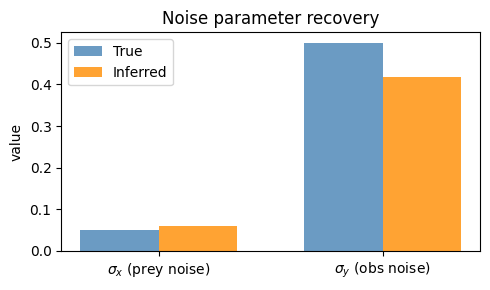

In [13]:
fig, ax = plt.subplots(figsize=(5, 3))

labels = ["$\\sigma_x$ (prey noise)", "$\\sigma_y$ (obs noise)"]
true_vals    = [sigma_x_true,    sigma_y_true]
inferred_vals = [sigma_x_inferred, sigma_y_inferred]

x = jnp.arange(len(labels))
width = 0.35

ax.bar(x - width / 2, true_vals,     width, label="True",     color="steelblue",  alpha=0.8)
ax.bar(x + width / 2, inferred_vals, width, label="Inferred",  color="darkorange", alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("value")
ax.set_title("Noise parameter recovery")
ax.legend()
plt.tight_layout()
plt.show()

## Filtered trajectories

Using the inferred parameters, run the conditioned model one more time to extract the EKF-filtered
state means and covariances.

/Users/danwaxman/Documents/dynestyx/dynestyx/models/core.py:228: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  return StochasticContinuousTimeStateEvolution(
/Users/danwaxman/.local/share/uv/python/cpython-3.12.10-macos-aarch64-none/lib/python3.12/dataclasses.py:1588: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  return obj.__class__(**changes)


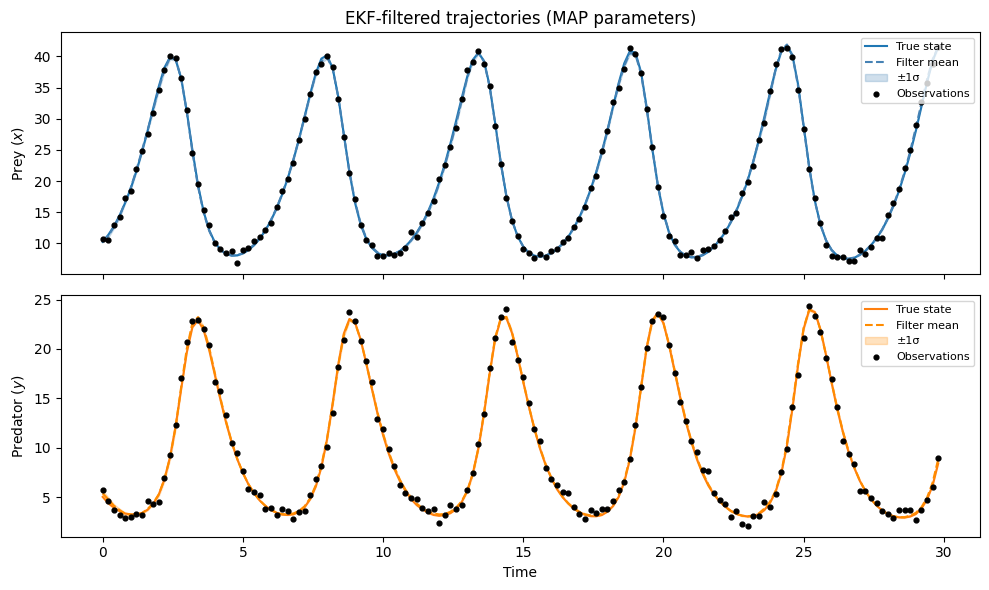

In [14]:
# Run the conditioned model with MAP params to extract filter means/variances.
# Important: AutoDelta stores unconstrained optimizer params in `svi_result.params`;
# for posterior predictive/filtering we must pass latent-site values explicitly.
map_params = {
    "Theta": Theta_inferred,
    "sigma_x": jnp.asarray(sigma_x_inferred),
    "sigma_y": jnp.asarray(sigma_y_inferred),
}

predictive_filter = Predictive(data_conditioned_model, params=map_params, num_samples=1)
pred_samples = predictive_filter(k_filter, obs_times=obs_times, obs_values=obs_values)

filtered_mean = pred_samples["f_filtered_states_mean"][0]   # (T or T+1, 2)
filtered_cov  = pred_samples["f_filtered_states_cov"][0]    # (T or T+1, 2, 2)
filtered_std  = jnp.sqrt(jnp.maximum(jnp.diagonal(filtered_cov, axis1=-2, axis2=-1), 1e-10))

# Some filters include a prior state at t0 (length T+1). Align to observations for plotting.
n = min(obs_times.shape[0], states.shape[0], obs_values.shape[0], filtered_mean.shape[0])
t_plot = obs_times[:n]
state_plot = states[:n]
obs_plot = obs_values[:n]
mean_plot = filtered_mean[:n]
std_plot = filtered_std[:n]

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

labels_state = ["Prey ($x$)", "Predator ($y$)"]
colors_true  = ["tab:blue", "tab:orange"]
colors_filt  = ["steelblue", "darkorange"]

for i, (ax, label, col_t, col_f) in enumerate(zip(axes, labels_state, colors_true, colors_filt)):
    # True latent trajectory
    ax.plot(t_plot, state_plot[:, i], lw=1.5, color=col_t, label="True state", zorder=3)

    # Filtered mean ± 1σ
    mu = mean_plot[:, i]
    std = std_plot[:, i]
    ax.plot(t_plot, mu, "--", lw=1.5, color=col_f, label="Filter mean", zorder=4)
    ax.fill_between(t_plot, mu - std, mu + std, color=col_f, alpha=0.25, label="±1σ")

    # Observations (both species)
    ax.scatter(t_plot, obs_plot[:, i], s=12, color="black", zorder=5, label="Observations")

    ax.set_ylabel(label)
    ax.legend(loc="upper right", fontsize=8)

axes[-1].set_xlabel("Time")
axes[0].set_title("EKF-filtered trajectories (MAP parameters)")
plt.tight_layout()
plt.show()

## Phase-space tracking with uncertainty ellipses

The same filtered posterior can be viewed in $(x, y)$ phase space. We overlay true states,
noisy observations, filtered means, and axis-aligned 1-sigma ellipses from the EKF covariance.

/var/folders/fx/6n6838cn51v4zyntllq4rxq80000gn/T/ipykernel_96383/3954310149.py:28: UserWarning: Legend does not support handles for PatchCollection instances.
A proxy artist may be used instead.
See: https://matplotlib.org/stable/users/explain/axes/legend_guide.html#controlling-the-legend-entries
  ax.legend(


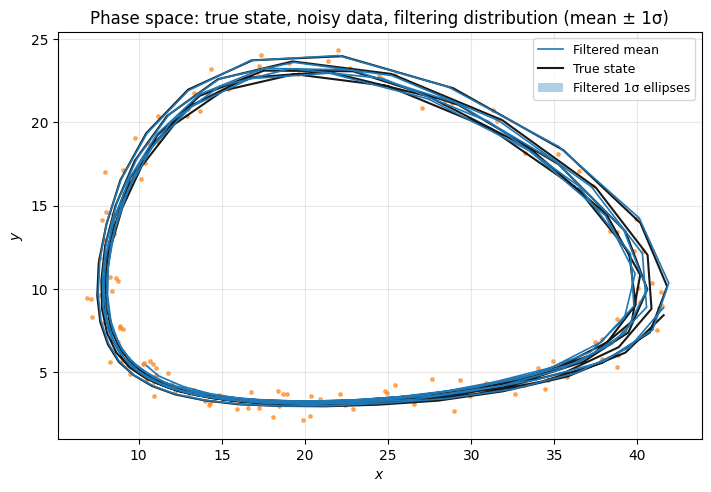

In [15]:
from matplotlib.patches import Ellipse, Rectangle
from matplotlib.collections import PatchCollection

# Align lengths in case filtering returns an extra prior state.
n = min(obs_values.shape[0], states.shape[0], filtered_mean.shape[0])
fm = filtered_mean[:n]
st = states[:n]
obs = obs_values[:n]

# Use previously computed std if available, otherwise derive from covariance.
if "filtered_std" in globals():
    fs = filtered_std[:n]
else:
    fs = jnp.sqrt(jnp.maximum(jnp.diagonal(filtered_cov[:n], axis1=-2, axis2=-1), 1e-10))

fig, ax = plt.subplots(figsize=(7, 6), constrained_layout=True)

ellipses = [
    Ellipse(xy=(fm[i, 0], fm[i, 1]), width=2 * fs[i, 0], height=2 * fs[i, 1])
    for i in range(len(fm))
]
ec = PatchCollection(ellipses, facecolor="C0", edgecolor="none", alpha=0.07)
ax.add_collection(ec)

ax.plot(st[:, 0], st[:, 1], "k-", label="True state", linewidth=1.5, alpha=0.9)
ax.scatter(obs[:, 0], obs[:, 1], s=6, c="C1", alpha=0.6, label="Noisy observations")
ax.plot(fm[:, 0], fm[:, 1], "C0-", label="Filtered mean", linewidth=1.2)
ax.legend(
    handles=[
        ax.lines[-1],
        ax.collections[-2],
        ax.lines[0],
        Rectangle((0, 0), 1, 1, facecolor="C0", alpha=0.35),
    ],
    labels=["Filtered mean", "Noisy observations", "True state", "Filtered 1σ ellipses"],
    loc="upper right", fontsize=9,
)

ax.set_xlabel("$x$")
ax.set_ylabel("$y$")
ax.set_title("Phase space: true state, noisy data, filtering distribution (mean ± 1σ)")
ax.grid(True, alpha=0.3)
ax.set_aspect("equal")
ax.autoscale_view()
plt.show()

## Summary

This notebook demonstrated **Universal ODEs (UODEs) for Bayesian system identification** on a Lotka-Volterra predator-prey system using the dynestyx library.

**Key take-aways:**

| Aspect | Details |
|--------|--------|
| **Known physics** | Linear self-regulation: $[\alpha x,\; -\delta y]$ |
| **Unknown interaction** | Polynomial library $\phi(x, y) = [1, x, y, x^2, xy, y^2]^\top$; Laplace(0, 0.005) prior promotes SINDy-like sparsity |
| **Both species observed** | $H = I_2$ at $\Delta t = 0.2$ (150 points); denser data breaks library-feature collinearity |
| **SVI (MAP)** | Fast point estimate using `AutoDelta` with ADAM optimizer |
| **Library changes** | **None** — arbitrary drift callables compose with existing `Filter` / `SDESimulator` handlers |

The recovered $\Theta$ concentrates mass on the $xy$ column, correctly identifying the predator--prey coupling.

The same pattern extends to any hybrid model: replace the polynomial library with a neural network to get a neural ODE / physics-informed neural network, or add additional known ODE terms for structured mechanistic learning.